In [6]:
%display latex

In [7]:
# Ініціалізація символьних змінних
var('t x h V gamma m t')

# --- 1. ФІЗИЧНІ КОНСТАНТИ ТА ПАРАМЕТРИ РАКЕТИ (Falcon 1) ---
g0 = 9.80665           # Прискорення вільного падіння (м/с^2)
Re = 6371000.0         # Радіус Землі (м)
rho0 = 1.225           # Щільність повітря на рівні моря (кг/м^3)
H_scale = 8500.0       # Шкала висоти атмосфери (м)

m0 = 27670.0           # Стартова маса (кг)
T = 454000.0           # Тяга двигуна (Н)
Isp = 275.0            # Питомий імпульс (с)
A = 2.27               # Площа лобового опору корпусу (м^2)
Cd = 0.3               # Коефіцієнт лобового опору
mu = T / (Isp * g0)    # Секундна витрата палива (кг/с)

In [ ]:
# Функції середовища
rho(h) = rho0 * exp(-h / H_scale)
g(h) = g0 * (Re / (Re + h))^2
D_body(h, V) = 0.5 * Cd * rho(h) * V^2 * A

In [ ]:
# СИСТЕМА 1: КЛАСИЧНИЙ СТАРТ (Gravity Turn)# ==============================================================================
eq_x1 = V * cos(gamma)
eq_h1 = V * sin(gamma)
eq_V1 = (T - D_body(h, V)) / m - g(h) * sin(gamma)
eq_gamma1 = -(g(h) / V) * cos(gamma) + (V / (Re + h)) * cos(gamma)
eq_m1 = -mu + 0*t # Початкові умови: [t=0, x=0, h=0.1, V=5.0, gamma=1.56, m=m0]# Швидкість беремо 10 м/с, кут 1.57 рад (~89.95 градуса) для ініціалізації повороту
ics_classic = [0, 0, 0.1, 10.0, 1.57, m0]
sol_classic = desolve_system_rk4(
    [eq_x1, eq_h1, eq_V1, eq_gamma1, eq_m1],
    [x, h, V, gamma, m],
    ics=ics_classic, ivar=t, end_points=130, step=0.5
)

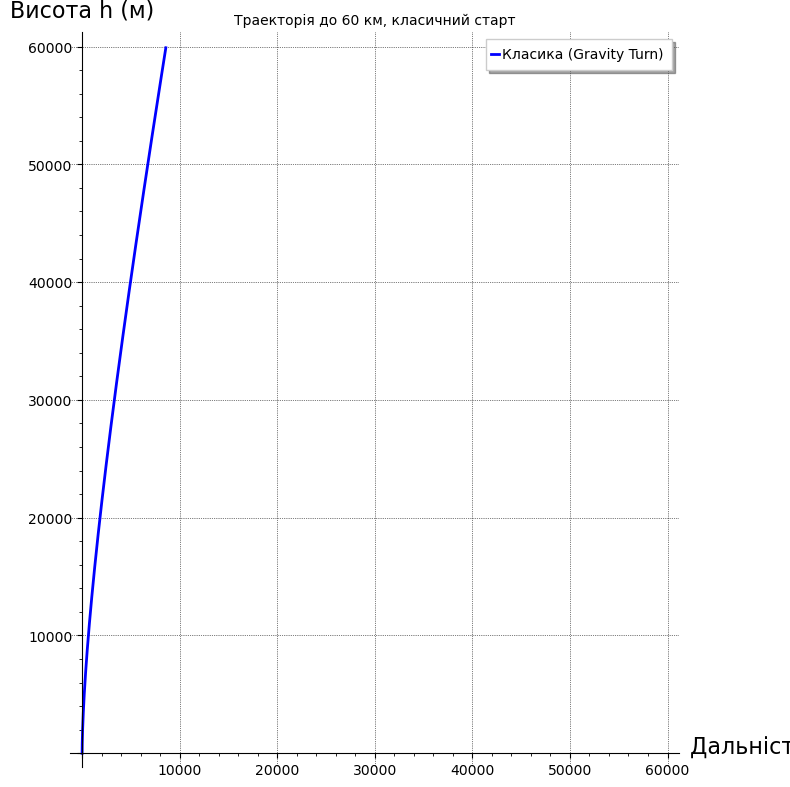

In [14]:
pts_classic = [(pt[1], pt[2]) for pt in sol_classic if pt[2] <= 60000]
plot_c = list_plot(pts_classic, plotjoined=True, color='blue', thickness=2, legend_label='Класика (Gravity Turn)')
trajectory_plot = plot_c
trajectory_plot.show(
    title="Траекторія до 60 км, класичний старт", 
    axes_labels=['Дальність x (м)', 'Висота h (м)'], 
    gridlines=True,
    figsize=(8, 8),      
    xmin=0, xmax=60000,  
    ymin=0, ymax=60000
)